In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
csv_semi_processed_path = os.path.join(project_root, "data", "raw", "PlantsTemperature_View_original.csv")
df_c = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [3]:
import  jdatetime
def jalali_to_gregorian_fast(date_str):
    jy, jm, jd = map(int, date_str.split('/'))
    jdate = jdatetime.date(jy, jm, jd)
    gdate = jdate.togregorian()
    return f"{gdate.year}-{gdate.month:02d}-{gdate.day:02d}"

In [4]:
df = df_c[(df_c['PowerPlantCode']==104)]
df = df.sort_values(by=['Date','HourNo'])
df["HourNo"] = df["HourNo"].astype(int)
df["Date"] = df["Date"].apply(jalali_to_gregorian_fast)
df["datetime"] = pd.to_datetime(df["Date"]) + pd.to_timedelta(df["HourNo"],unit='h')
df.head()

,PowerPlantCode,PowerPlantName,Date,Name,InsertDateTime,HourNo,Value,Code,datetime
0,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,1,11.38,SCADAF,2021-03-21 01:00:00
1,104,پرند,2021-03-21,سنسور دمای نیروگاه,1401/05/05-08:59:01.06,1,12.97,TempSens,2021-03-21 01:00:00
2,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,2,10.32,SCADAF,2021-03-21 02:00:00
3,104,پرند,2021-03-21,سنسور دمای نیروگاه,1401/05/05-08:59:01.06,2,9.36,TempSens,2021-03-21 02:00:00
4,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,3,11.02,SCADAF,2021-03-21 03:00:00


In [5]:
is_env = df["Code"] == "SCADAF"

In [6]:
df_sen = df[~is_env]
df_env = df[is_env]
len(df_sen),len(df_env)

(26191, 34751)

In [7]:
import numpy as np
a, b = np.unique(df['datetime'].to_numpy(), return_counts=True)
a1, b1 = np.unique(df_env['datetime'].to_numpy(), return_counts=True)
a2, b2 = np.unique(df_sen['datetime'].to_numpy(), return_counts=True)

In [8]:
def show_date(dates):
    dates = dates.copy()
    full_range = pd.date_range(start=dates.min(), end=dates.max(), freq='h')
    df = pd.DataFrame({'datetime': full_range})
    df['Value'] = 0
    df.loc[df['datetime'].isin(dates), 'Value'] = 1
    plt.figure(figsize=(12, 6))
    plt.plot(df['datetime'], df['Value'], drawstyle='steps-post', marker='.')
    plt.xlabel('Date and Time')
    plt.ylabel('Value')
    plt.title('Date and Time Presence')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
    return df[df['Value'] == 0]["datetime"]

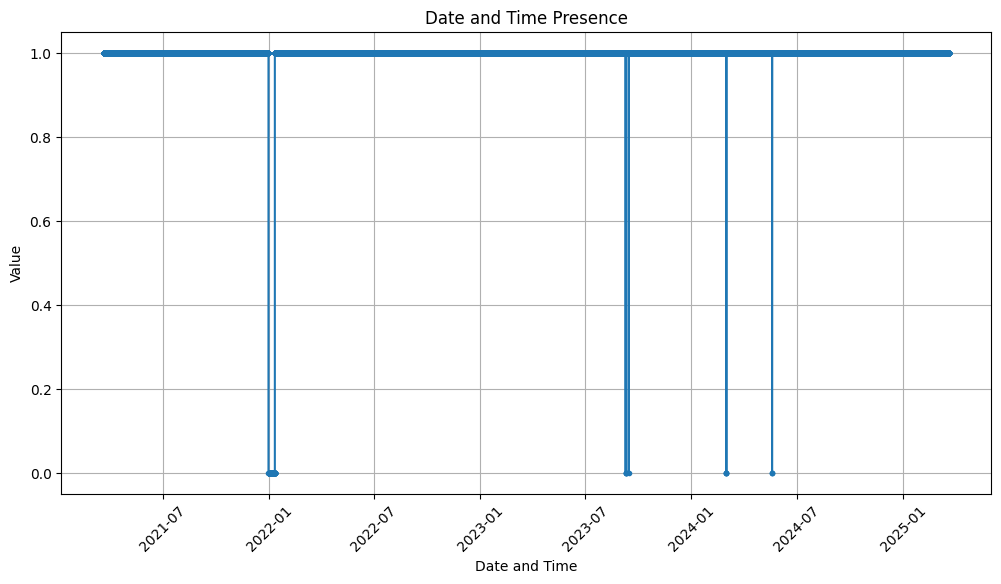

278 16
2021-12-31 23 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-01 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-02 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-03 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-04 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-05 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-06 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-07 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-08 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-09 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20

In [9]:
datestimes = show_date(a)
datess = datestimes.dt.date
print(len(datestimes),len(datess.unique()))
for d in datess.unique():
    t = datestimes[datess == d].dt.hour.to_list()
    print(d,len(t),t)

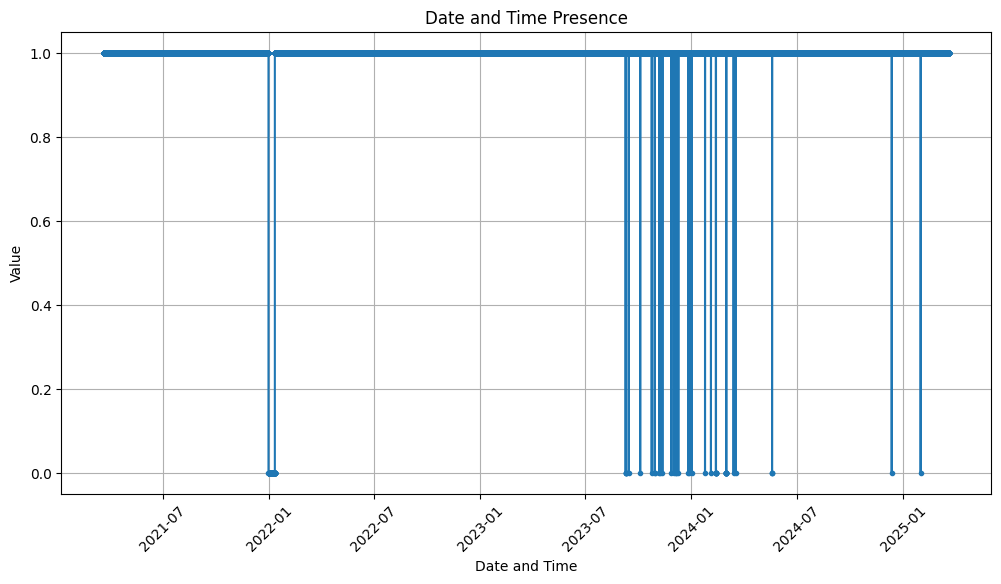

313 38
2021-12-31 23 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-01 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-02 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-03 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-04 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-05 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-06 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-07 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-08 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-09 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20

In [10]:
datestimes = show_date(a1)
datess = datestimes.dt.date
print(len(datestimes),len(datess.unique()))
for d in datess.unique():
    t = datestimes[datess == d].dt.hour.to_list()
    print(d,len(t),t)

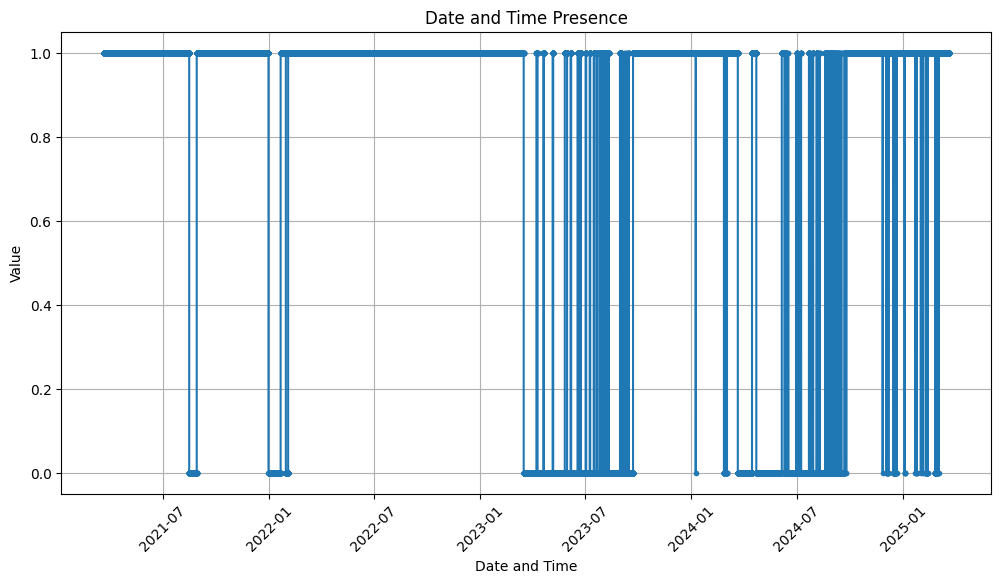

8873 433
2021-08-16 23 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-17 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-18 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-19 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-20 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-21 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-22 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-23 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-24 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-25 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 

In [11]:
datestimes = show_date(a2)
datess = datestimes.dt.date
print(len(datestimes),len(datess.unique()))
for d in datess.unique():
    t = datestimes[datess == d].dt.hour.to_list()
    print(d,len(t),t)

In [12]:
len(df_sen),len(df_env)

(26191, 34751)

In [13]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df_s = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [14]:
#t = "1400/01/01"
#df_sen = df_sen[df_sen["Date"] == t]
#df_env = df_env[df_env["Date"] == t]

In [15]:
tem_sen = df_sen["Value"].values
tem_env = df_env["Value"].values

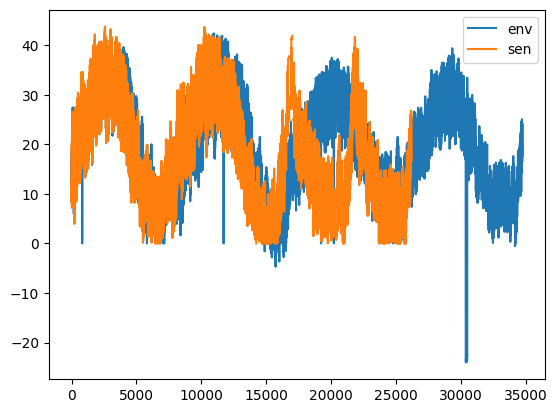

In [16]:
plt.plot(tem_env, label="env")
plt.plot(tem_sen, label='sen')
plt.legend()
plt.show()

In [17]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df_s = pd.read_csv(csv_semi_processed_path, encoding='utf-8')
df_s['date'] = pd.to_datetime(df_s['date'])
df_s['datetime'] = df_s['date'] + pd.to_timedelta(df_s['hour'], unit='h')

In [18]:
from src.visualization.plotUnit import UnitPlotter

In [19]:
'''
df_s2 = df_s[(df_s['name'] == "پرند") & (df_s['code'] == 'G11') & (df_s["is_good_peak"] >= 3)]
df_merged = pd.merge(df_s2, df_env, on="datetime", how="inner")
print(len(df_merged), len(df_s2))
my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']].dropna()
#my_cols.dropna(inplace=True)
gens = my_cols['generation'].values
temp_senses = my_cols['Value'].values
plt.scatter(temp_senses, gens, s=0.5)
plt.show()
'''

'\ndf_s2 = df_s[(df_s[\'name\'] == "پرند") & (df_s[\'code\'] == \'G11\') & (df_s["is_good_peak"] >= 3)]\ndf_merged = pd.merge(df_s2, df_env, on="datetime", how="inner")\nprint(len(df_merged), len(df_s2))\nmy_cols = df_merged[[\'date\', \'hour\', \'temperature\', \'Value\', \'generation\']].dropna()\n#my_cols.dropna(inplace=True)\ngens = my_cols[\'generation\'].values\ntemp_senses = my_cols[\'Value\'].values\nplt.scatter(temp_senses, gens, s=0.5)\nplt.show()\n'

In [21]:
import plotly.express as px
import plotly.graph_objects as go


In [ ]:
power_plants = df_s[['name', 'code']].drop_duplicates()
for _, row in power_plants.iterrows():
    name, code = row['name'], row['code']

    # فیلتر کردن داده‌ها
    df_s2 = df_s[(df_s['name'] == name) & (df_s['code'] == code) & (df_s["is_good_peak"] >= 0)]
    df_merged = pd.merge(df_s2, df_sen, on="datetime", how="inner")
    print(len(df_merged), len(df_s2))

    # انتخاب ستون‌های مورد نیاز و حذف مقادیر NaN
    my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']].dropna()
    gens = my_cols['generation'].values
    temp_senses = my_cols['Value'].values

    # ایجاد نمودار پراکندگی
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=temp_senses,
        y=gens,
        mode='markers',
        marker=dict(
            size=3,
            opacity=0.6,
            color='blue'
        ),
        name='داده‌های تولید'
    ))

    fig.update_layout(
        title=f'نمودار پراکندگی دمای حس شده vs تولید - {name+"-"+code}',
        xaxis_title='دمای حس شده',
        yaxis_title='تولید (مگاوات)',
        template='plotly_white'
    )

    fig.write_html(f"{project_root}/src/visualization/unit_figs/generation_vs_temeperature/{name}-{code}.html")

11448 12360
11448 12360
11448 12360
11448 12360
25454 34296
11448 12360
11448 12360
11448 12360
25454 34296
11448 12360
11448 12360
11448 12360
11448 12360
25454 34296
11448 12336
11448 12336
11448 12336
11448 12336
11448 12360
11448 12336
25454 34272
11448 12360
11448 12360
11448 12360
11448 12360
11448 12360
25454 34296
11448 12360
25454 34296
8257 9145
11448 12360
11448 12360
11448 12360
25454 34296
11448 12360
11448 12360
11448 12360
11448 12360
4153 4153
11448 12360
11448 12360
11448 12360
11448 12360
11448 12360
25454 34296
25454 34296
11448 12360
10320 11232
11448 12360
11448 12360
11448 12360
11448 12360


In [ ]:
def draw(df_s,row):
    name, code = row['name'], row['code']

    # فیلتر کردن داده‌ها
    df_s2 = df_s[(df_s['name'] == name) & (df_s['code'] == code) & (df_s["is_good_peak"] >= 0)]
    df_merged = pd.merge(df_s2, df_sen, on="datetime", how="inner")
    print(len(df_merged), len(df_s2))

    # انتخاب ستون‌های مورد نیاز و حذف مقادیر NaN
    my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']].dropna()
    gens = my_cols['generation'].values
    temp_senses = my_cols['Value'].values

    # ایجاد نمودار پراکندگی
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=temp_senses,
        y=gens,
        mode='markers',
        marker=dict(
            size=3,
            opacity=0.6,
            color='blue'
        ),
        name='داده‌های تولید'
    ))

    fig.update_layout(
        title=f'نمودار پراکندگی دمای حس شده vs تولید - {name+"-"+code}',
        xaxis_title='دمای حس شده',
        yaxis_title='تولید (مگاوات)',
        template='plotly_white'
    )

    fig.write_html(f"{project_root}/src/visualization/unit_figs/generation_vs_temeperature/{name}-{code}.html")
draw(df_s,{'name':'سیکل ترکیبی یزد','code':'G11'})